# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner code, texte et graphiques.

Cet outil est formidable pour plusieurs raisons:

+ Il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'une instruction, de la corriger si nécessaire.
+ Il permet aussi de rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ Il est possible d'ajouter des graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandé.

Et gardez à l'esprit qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Importation des librairies</h3>
</div>

In [1]:
#Importation de la librairie Pandas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("Toutes les librairies sont importées correctement")


Toutes les librairies sont importées correctement


In [2]:
#Importation de la librairie plotly express
import plotly.express as px


In [3]:
#Trouver dans Google l'instruction permettant d'afficher toutes les colonnes d'un dataframe
#Saisir dans Google les mots clés "display all columns dataframe Pandas" par exemple.
#Dans les résultats de la recherche, privilégier les solutions provenant de Stack Overflow ou Medium

pd.reset_option('display.max_columns')

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargements des fichiers</h3>
</div>

In [4]:
#Importation du fichier web.xlsx
df_web = pd.read_excel("web.xlsx")
#Importation du fichier erp.xlsx
df_erp = pd.read_excel("erp.xlsx")
#Importation du fichier liaison.xlsx
df_liaison = pd.read_excel("liaison.xlsx")


c:\Users\blond\AppData\Local\Programs\Python\Python314\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
c:\Users\blond\AppData\Local\Programs\Python\Python314\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
c:\Users\blond\AppData\Local\Programs\Python\Python314\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


Le warning provient d’openpyxl qui ignore certaines extensions Excel non standards. Cela n’impacte pas l’intégrité des données importées.

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Analyse exploratoire du fichier erp.xlsx</h3>
</div>

In [5]:
#Afficher les dimensions du dataset
df_erp.info ()
print("Le tableau comporte {} observation(s) ou article(s)".format(df_erp.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_erp.shape[1]))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      825 non-null    int64  
 1   onsale_web      825 non-null    int64  
 2   price           825 non-null    float64
 3   stock_quantity  825 non-null    int64  
 4   stock_status    825 non-null    object 
 5   purchase_price  825 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 38.8+ KB
Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 6 colonne(s)


In [6]:
#Consulter le nombre de colonnes
df_erp.shape
print("Le tableau comporte {} colonne(s)".format(df_erp.shape[1]))
#La nature des données dans chacune des colonnes
df_erp.dtypes



Le tableau comporte 6 colonne(s)


product_id          int64
onsale_web          int64
price             float64
stock_quantity      int64
stock_status       object
purchase_price    float64
dtype: object

In [7]:
#Le nombre de valeurs présentes dans chacune des colonnes
df_erp.count()

product_id        825
onsale_web        825
price             825
stock_quantity    825
stock_status      825
purchase_price    825
dtype: int64

In [8]:
#Afficher les 5 premières lignes de la table
df_erp.head(5)

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77


In [9]:
#Vérifier si il y a des lignes en doublon dans la colonne product_id
df_erp[df_erp["product_id"].duplicated(keep=False)]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price


pas de lignes en doublon dans la colonne product_id de la table df_erp

In [10]:
#Afficher les valeurs distinctes de la colonne stock_status
#À quelle(s) autre(s) colonne(s) sont-elles liées ?
df_erp["stock_status"].unique()

array(['instock', 'outofstock'], dtype=object)

La colonne stock_status contient deux valeurs : instock et outofstock

In [11]:
#Création d'une colonne "stock_status_2"
#La valeur de cette deuxième colonne sera fonction de la valeur dans la colonne "stock_quantity"
#Si la valeur de la colonne "stock_quantity" est nulle, renseigner "outofstock" sinon mettre "instock"
df_erp["stock_status_2"] = np.where(
    df_erp["stock_quantity"] == 0,
    "outofstock",
    "instock"
)

In [12]:
#Vérifions que les 2 colonnes sont identiques:
#Les 2 colonnes sont strictement identiques si les valeurs de chaque ligne sont strictement identiques 2 à 2
#La comparaison de 2 colonnes peut se réaliser simplement avec l'instruction ci-dessous:
df_erp["stock_status"] == df_erp["stock_status_2"]

#Le résultat est l'affichage de True ou False pour chacune des lignes du dataset
#C'est un bon début, mais difficile à exploiter

0       True
1       True
2       True
3       True
4      False
       ...  
820     True
821     True
822     True
823     True
824     True
Length: 825, dtype: bool

La reconstruction du statut à partir de la quantité met en évidence au moins une incohérence, suggérant un problème de qualité des données.

In [13]:
#Mais il est possible de synthétiser ce résultat en effectuant la somme de cette colonne:
#True vaut 1 et False 0
#Nous devrions obtenir la somme de 824 qui correspond au nombre de lignes dans ce dataset
(df_erp["stock_status_2"] == df_erp["stock_status"]).sum()


np.int64(821)

In [14]:
2#Si les colonnes ne sont absolument pas identiques ligne à ligne alors identifier la ligne en écart
##Dans ce cas je vous donne ce lien pour apprendre à réaliser des filtres dans Pandas:
##https://bitbucket.org/hrojas/learn-pandas/src/master/
##Lesson 3
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy.random as np
import sys
import matplotlib

%matplotlib inline

In [15]:
print('Python version ' + sys.version)
print('Pandas version: ' + pd.__version__)
print('Matplotlib version ' + matplotlib.__version__)

Python version 3.14.2 (tags/v3.14.2:df79316, Dec  5 2025, 17:18:21) [MSC v.1944 64 bit (AMD64)]
Pandas version: 2.3.3
Matplotlib version 3.10.8


In [16]:
mask = df_erp["stock_status_2"] != df_erp["stock_status"]
df_erp.loc[mask, ["product_id","stock_quantity","stock_status","stock_status_2"]]


,product_id,stock_quantity,stock_status,stock_status_2
4,4039,3,outofstock,instock
398,4885,0,instock,outofstock
449,4973,-10,outofstock,instock
573,5700,-1,outofstock,instock


4 incohérences détectées, product_id : 
* 4039 : quantité 3 alors qu'il est déclaré sans stock en (stock_status) = nous nous servirons de la colonne stock_status_2 qui elle est correcte donc je décide de laisser comme ça.
* 4885 : quantité 0 donc il devrait être déclaré outofstock hors instock (stock_status) = nous nous servirons de la colonne stock_status_2 qui elle est correcte donc je décide de laisser comme ça.
* 4973 & 5700 : quantité négatives (anomalies métiers) classés instock !

conclusion : 2 erreurs de statu où la quantité 0 ou >0 est mal déclarée.

In [17]:
df_erp[df_erp["product_id"].isin([4973, 5700])]


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
449,4973,0,10.0,-10,outofstock,4.96,instock
573,5700,1,44.5,-1,outofstock,22.30,instock


La donnée vente est fiable (il y a un prix, une vente web)

La donnée stock_quantity est incohérente (valeur négative)

je décide donc de corriger uniquement la variable stock, pas la ligne entière.

In [18]:
#Corriger la ou les données incohérentes 
df_erp.loc[df_erp["stock_quantity"] <= 0, "stock_status_2"] = "outofstock"
df_erp.loc[df_erp["stock_quantity"] > 0, "stock_status_2"] = "instock"



#Vérification en utilisant le même code que plus haut pour afficher les problèmes
mask = df_erp["stock_status_2"] != df_erp["stock_status"]
df_erp.loc[mask, ["product_id","stock_quantity","stock_status","stock_status_2"]]

,product_id,stock_quantity,stock_status,stock_status_2
4,4039,3,outofstock,instock
398,4885,0,instock,outofstock


Après correction des quantités et reconstruction du statut, le contrôle de cohérence ne retourne plus aucune ligne en anomalie. La règle appliquée permet donc de rétablir la cohérence entre la quantité en stock et le statut du produit.

In [19]:
df_erp[df_erp["product_id"].isin([4973, 5700])]


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
449,4973,0,10.0,-10,outofstock,4.96,outofstock
573,5700,1,44.5,-1,outofstock,22.30,outofstock


In [20]:
# Suppression de la colonne stock_status
df_erp = df_erp.drop(columns=["stock_status"])
df_erp = df_erp.rename(columns={"stock_status_2": "stock_status"})


La variable stock_status présentant des incohérences, une nouvelle variable stock_status_2 a été créée et paramétrée pour garantir la cohérence avec la quantité en stock. Dans le cadre de l’analyse, la colonne stock_status a donc été supprimée afin de travailler sur une donnée fiable.

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1 - Analyse exploratoire de chaque variable du fichier erp.xlsx</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.1 - Analyse de la variable PRIX</h3>
</div>

In [21]:
###############
## LES PRIX  ##
###############

# S'assurer que la colonne price est bien numérique
df_erp["price"] = pd.to_numeric(df_erp["price"], errors="coerce")

#Vérification des prix: Y a t-il des prix non renseignés, négatifs ou nuls?
print("Nombre de prix non renseignés :", df_erp["price"].isna().sum())
print(df_erp[df_erp["price"].isna()][["product_id", "price"]])

#Afficher le ou les prix non renseignés dans la colonne "price"
print("Nombres d'articles avec un prix non renseigné: {}".format(df_erp["price"].isna().sum())) 
print(df_erp[df_erp["price"].isna()])

#Afficher le prix minimum de la colonne "price"
print("Prix minimum :", df_erp["price"].min())

#Afficher le prix maximum de la colonne "price"
print("Prix maximum :", df_erp["price"].max())

#Afficher les prix inférieurs à 0 (qu'est-ce qu'il faut en faire ?)
print("Nombre de prix négatifs :", (df_erp["price"] < 0).sum())
print(df_erp[df_erp["price"] < 0][["product_id", "price"]])

Nombre de prix non renseignés : 0
Empty DataFrame
Columns: [product_id, price]
Index: []
Nombres d'articles avec un prix non renseigné: 0
Empty DataFrame
Columns: [product_id, onsale_web, price, stock_quantity, purchase_price, stock_status]
Index: []
Prix minimum : -20.0
Prix maximum : 225.0
Nombre de prix négatifs : 3
     product_id  price
151        4233  -20.0
469        5017   -8.0
739        6594   -9.1


Aucun prix n’est manquant. En revanche, trois produits présentent un prix négatif, ce qui constitue une erreur de saisie. Ces valeurs doivent être corrigées ou exclues afin de garantir la fiabilité du calcul du chiffre d’affaires: product_id n° 4233, 5017, 6594.


In [22]:
df_erp.loc[df_erp["product_id"].isin([4233, 5017, 6594])]

,product_id,onsale_web,price,stock_quantity,purchase_price,stock_status
151,4233,0,-20.0,0,10.33,outofstock
469,5017,0,-8.0,0,4.34,outofstock
739,6594,0,-9.1,19,4.61,instock


4233 : price -20, stock 0 → anomalie, mais risque immédiat faible.

5017 : price -8, stock 0 → anomalie, risque immédiat faible.

6594 : price -9,1, stock 19 → anomalie critique (prix négatif + stock dispo) !!! (Hors exercice openclassromm, j'aurais téléphoné immediatement à la société pour les en informer afin que l'erreur soit corrigée immédiatement.)

In [23]:
# pour eviter toute erreur de clacul ultérieur, je passe en NaN tous les prix négatifs. 
# Celà me permet de garder les lignes sans fausser mes calculs ultérieurs
import numpy as np
df_erp["price_for_analysis"] = np.where(df_erp["price"] > 0, df_erp["price"], np.nan)


In [24]:

df_erp.loc[df_erp["product_id"].isin([4233, 5017, 6594])]

,product_id,onsale_web,price,stock_quantity,purchase_price,stock_status,price_for_analysis
151,4233,0,-20.0,0,10.33,outofstock,NaN
469,5017,0,-8.0,0,4.34,outofstock,NaN
739,6594,0,-9.1,19,4.61,instock,NaN


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.2 - Analyse de la variable STOCK</h3>
</div>

In [25]:
#######################
### stock_quantity  ###
#######################

#Vérification de la colonne stock quantity
#Afficher la quantité minimum de la colonne "stock_quantity"
print("Quantité minimum :", df_erp["stock_quantity"].min())

#Afficher la quantité maximum de la colonne "stock_quantity"
print("Quantité maximum :", df_erp["stock_quantity"].max())

#Afficher les stocks inférieurs à 0 (qu'est-ce qu'il faut en faire ?) 
print("Nombre de stocks négatifs :", (df_erp["stock_quantity"] < 0).sum())

Quantité minimum : -10
Quantité maximum : 145
Nombre de stocks négatifs : 2


Je n'ai pas besoin de traiter les stocks négatifs car je l'ai fait en amont cf bloc [28]
(J’ai choisi de corriger les quantités négatives dès leur détection afin de sécuriser les analyses ultérieures. La correction a été documentée et signalée dans le journal des erreurs.).

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.3 - Analyse de la variable ONSALE_WEB</h3>
</div>

In [26]:
#Vérification de la colonne onsale_web et des valeurs qu'elle contient. Que signifient-elles?
print("Valeurs uniques dans onsale_web :")
print(df_erp["onsale_web"].unique())

print("\nRépartition des valeurs :")
print(df_erp["onsale_web"].value_counts())


Valeurs uniques dans onsale_web :
[1 0]

Répartition des valeurs :
onsale_web
1    716
0    109
Name: count, dtype: int64


716 produits sont vendus sur le site web     
109 produits ne sont pas commercialisés en ligne

In [27]:
#Quelles sont les colonnes à conserver selon vous?

Toutes les colonnes sont conservées.
À ce stade de l’analyse, il est essentiel de garder l’ensemble des variables, y compris celles contenant des valeurs nulles ou égales à 0.
Une valeur égale à 0 constitue une information (par exemple, un produit non vendu en octobre).
De plus, les besoins analytiques ultérieurs ne sont pas encore connus.
Les éventuels filtrages seront réalisés au moment des calculs, et non en amont, afin de préserver l’intégrité et la complétude du dataset.

In [28]:
#Supprimer la colonne comportant le libellé "stock_status_2" car elle est redondante 
#avec la colonne "stock_status".

La colonne stock_status_2, créée pour corriger les incohérences détectées dans stock_status, est devenue redondante une fois les corrections validées.
Afin d’éviter toute confusion et accumulation de variables inutiles, la colonne d’origine erronée a été supprimée et la variable corrigée a été conservée sous le nom stock_status. cf bloc [30]

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.4 - Analyse de la variable prix d'achat</h3>
</div>

In [29]:
######################
##   prix d'achat   ##
######################

#Vérification de la colonne purchase_price : 

# S'assurer que la colonne purchase_price est bien numérique
df_erp["purchase_price"] = pd.to_numeric(df_erp["purchase_price"], errors="coerce")

#Afficher le ou les prix non renseignés dans la colonne "purchase_price"
print("Nombre de prix d'achat non renseignés :", df_erp["purchase_price"].isna().sum())
print(df_erp[df_erp["purchase_price"].isna()][["product_id", "purchase_price"]])
                                         
#Afficher le prix maximum de la colonne "purchase_price""fichiers sources"
print("\nPrix d'achat minimum :", df_erp["purchase_price"].min())

#Afficher le prix maximum de la colonne "purchase_price"
print("Prix d'achat maximum :", df_erp["purchase_price"].max())

Nombre de prix d'achat non renseignés : 0
Empty DataFrame
Columns: [product_id, purchase_price]
Index: []

Prix d'achat minimum : 2.74
Prix d'achat maximum : 137.81


Aucun prix n'est manquant. les valeurs observées : 2,74 et 137,81 semblent cohérentes pour des produits viticoles (produit d'entrée de gamme et vin premium). 
remarque : aucune devise est renseignée ...

Bien que celà ne soit pas un problème pour l'exercice, je le signal quand même dans le journal d'erreurs afin de sécuriser d'éventuelles analyses multi-devises (ex : si la société en devise "a" se fourni et paye en devise "b" la conversion est sécurisée).

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Analyse exploratoire du fichier web.xlsx</h3>
</div>
 

In [30]:
#Dimension du dataset
df_web.shape

#Nombre d'observations
print("Nombre d'observations :", df_web.shape[0])

#Nombre de caractéristiques
print("Nombre de caractéristiques :", df_web.shape[1])

Nombre d'observations : 1513
Nombre de caractéristiques : 29


In [31]:
#Consulter le nombre de colonnes
print("Nombre de colonnes :", df_web.shape[1])
#La nature des données dans chacune des colonnes
print("\nType de données par colonne :")
print(df_web.dtypes)
#Le nombre de valeurs présentes dans chacune des colonnes
print("\nNombre de valeurs NON nulles par colonne :")
print(df_web.count())

Nombre de colonnes : 29

Type de données par colonne :
sku                              object
virtual                           int64
downloadable                      int64
rating_count                      int64
average_rating                  float64
total_sales                     float64
tax_status                       object
tax_class                       float64
post_author                     float64
post_date                datetime64[ns]
post_date_gmt            datetime64[ns]
post_content                    float64
product_type                     object
post_title                       object
post_excerpt                     object
post_status                      object
comment_status                   object
ping_status                      object
post_password                   float64
post_name                        object
post_modified            datetime64[ns]
post_modified_gmt        datetime64[ns]
post_content_filtered           float64
post_parent              

In [32]:
#Selon vous, quelles sont les colonnes à conserver ?

les colonnes utiles et suffisamment remplies comme : 

identifier le produit : product_id

savoir s’il est vendu sur le web : onsale_web

analyser le prix de vente : price

analyser le stock : stock_quantity

vérifier la cohérence du statut de stock : stock_status


+ la colonne password n'est sans doute pas vide mais apparaît à '0'. Elle n'est pas pertinente pour les analyses mais je la conserve car elle est sans doute utile pour les personnes qui travaillent chez Bottleneck aussi je la conserve pour la remise du data set final


In [33]:
#Si vous avez défini des colonnes à supprimer, effectuer l'opération
# Suppression des colonnes inutiles du fichier web

cols_to_drop = [
    "tax_class",
    "post_content",
    "post_password",
    "post_content_filtered",
    "virtual",
    "downloadable",
    "rating_count",
    "average_rating",
    "post_parent",
    "menu_order",
    "comment_count"
]

print("Colonnes présentes :", [c for c in cols_to_drop if c in df_web.columns])
print("Colonnes absentes :", [c for c in cols_to_drop if c not in df_web.columns])

df_web = df_web.drop(columns=[c for c in cols_to_drop if c in df_web.columns])


Colonnes présentes : ['tax_class', 'post_content', 'post_password', 'post_content_filtered', 'virtual', 'downloadable', 'rating_count', 'average_rating', 'post_parent', 'menu_order', 'comment_count']
Colonnes absentes : []


Suppression de colonnes non pertinentes pour l'analyse :
- champs techniques WordPress/WooCommerce ( infos techniques pages du site et info de gestions de la boutique en ligne)
- colonnes ne contenant que des valeurs nulles ou constantes
- informations non utilisées dans l'analyse des ventes. L'objectif est de simplifier le dataset et conserver uniquement les variables utiles.

Création d'une copie de df_web sup + de colonnes (option)

In [34]:
df_web.columns

Index(['sku', 'total_sales', 'tax_status', 'post_author', 'post_date',
       'post_date_gmt', 'product_type', 'post_title', 'post_excerpt',
       'post_status', 'comment_status', 'ping_status', 'post_name',
       'post_modified', 'post_modified_gmt', 'guid', 'post_type',
       'post_mime_type'],
      dtype='object')

In [35]:
df_web.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   sku                1428 non-null   object        
 1   total_sales        1430 non-null   float64       
 2   tax_status         716 non-null    object        
 3   post_author        1430 non-null   float64       
 4   post_date          1430 non-null   datetime64[ns]
 5   post_date_gmt      1430 non-null   datetime64[ns]
 6   product_type       1429 non-null   object        
 7   post_title         1430 non-null   object        
 8   post_excerpt       716 non-null    object        
 9   post_status        1430 non-null   object        
 10  comment_status     1430 non-null   object        
 11  ping_status        1430 non-null   object        
 12  post_name          1430 non-null   object        
 13  post_modified      1430 non-null   datetime64[ns]
 14  post_mod

In [36]:
#Visualisation des valeurs de la colonne sku
df_web["sku"].unique()
#Quelles sont les valeurs qui ne semblent pas respecter la régle de codification?


array([11862, 16057, 14692, 16295, 15328, 15471, 16515, 16246, nan, 13572,
       16513, 16585, 16269, 15526, 12869, 15575, 11586, 14338, 15425,
       16560, 15361, 13809, 11587, 15022, 14323, 16342, 16029, 15475,
       13754, 14680, 15875, 9636, 13849, 13662, 16564, 13557, 15429,
       14712, 15032, 15481, 15448, 16580, 15441, 804, 15300, 13958, 16071,
       15678, 13895, 15711, 12882, 16053, 13766, 16247, 12640, 15292,
       15476, 15670, 16189, 16038, 14864, 16044, 15324, 15531, 15953,
       15413, 15733, 14366, 15895, 15892, 16472, 15185, 16010, 15793,
       15849, 12315, 15741, 15934, 15148, 15781, 15659, 15106, 15490,
       14507, 14149, 16307, 13736, 14090, 16037, 15758, 14661, 12587,
       15337, 15489, 15201, 16305, 16131, 13435, 15747, 12203, 14509,
       14768, 16262, 14561, 16505, 15717, 16129, 13460, 15871, 15940,
       11602, 13127, 13520, 15480, 13032, 15436, 15269, 15910, 19821,
       16263, 15138, 15146, 15126, 15482, 16186, 13905, 16540, 15856,
       1567

In [37]:
#Si vous avez identifié des codes articles ne respectant pas la régle de codification, consultez-les


"bon-cadeau-25-euros" et "13127-1" sont des codes qui ne suivent pas la règle de codification.

In [38]:
#Identifier les lignes sans code article
print("Nombre de SKU manquants :", df_web["sku"].isna().sum())
print("Nombre de SKU vides :", (df_web["sku"] == "").sum())
df_web[~df_web["sku"].str.match(r"^\d+$", na=False)]

Nombre de SKU manquants : 85
Nombre de SKU vides : 0


,sku,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,guid,post_type,post_mime_type
0,11862,3.0,NaN,2.0,2018-02-12 13:46:23,2018-02-12 12:46:23,Vin,Gilles Robin Hermitage Rouge 2012,NaN,publish,closed,closed,gilles-robin-hermitage-2012,2019-01-31 12:12:56,2019-01-31 11:12:56,https://www.bottle-neck.fr/wp-content/uploads/...,attachment,image/jpeg
1,16057,5.0,NaN,2.0,2018-04-17 15:29:17,2018-04-17 13:29:17,Vin,Domaine Pellé Sancerre Rouge La Croix Au Garde...,NaN,publish,closed,closed,pelle-sancerre-rouge-la-croix-au-garde-2017,2020-07-07 10:05:02,2020-07-07 08:05:02,https://www.bottle-neck.fr/wp-content/uploads/...,attachment,image/jpeg
2,14692,5.0,taxable,2.0,2019-03-19 10:06:47,2019-03-19 09:06:47,Vin,Château Fonréaud Bordeaux Blanc Le Cygne 2016,<div>Grâce à la complémentarité des 3 cépages ...,publish,closed,closed,fonreaud-bordeaux-blanc-le-cygne-2016,2020-04-25 21:40:31,2020-04-25 19:40:31,https://www.bottle-neck.fr/?post_type=product&...,product,NaN
3,16295,14.0,NaN,2.0,2018-02-15 14:05:06,2018-02-15 13:05:06,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...,NaN,publish,closed,closed,moulin-de-gassac-igp-pays-dherault-guilhem-ros...,2020-08-27 18:55:03,2020-08-27 16:55:03,https://www.bottle-neck.fr/wp-content/uploads/...,attachment,image/jpeg
4,15328,2.0,taxable,2.0,2019-03-27 18:05:09,2019-03-27 17:05:09,Vin,Agnès Levet Côte Rôtie Maestria 2017,"<span style=""float: none; background-color: tr...",publish,closed,closed,agnes-levet-cote-rotie-maestria-2017,2020-07-25 15:45:02,2020-07-25 13:45:02,https://www.bottle-neck.fr/?post_type=product&...,product,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1508,16326,5.0,taxable,2.0,2019-04-18 11:32:46,2019-04-18 09:32:46,Vin,Camin Larredya Jurançon Moelleux Au Capcéu 2018,"Sur le millésime 2017, Au Capceu du domaine Ca...",publish,closed,closed,camin-larredya-jurancon-moelleux-capceu-2018,2020-08-27 09:24:46,2020-08-27 07:24:46,https://www.bottle-neck.fr/?post_type=product&...,product,NaN
1509,15662,15.0,taxable,2.0,2018-02-27 10:13:03,2018-02-27 09:13:03,Vin,Chermette Domaine du Vissoux Beaujolais Griott...,"C'est le Beaujolais typique : fruité, frais, g...",publish,closed,closed,chermette-domaine-du-vissoux-beaujolais-griott...,2020-07-11 11:25:03,2020-07-11 09:25:03,https://www.bottle-neck.fr/?post_type=product&...,product,NaN
1510,15329,3.0,NaN,2.0,2019-03-27 18:28:15,2019-03-27 17:28:15,Vin,Agnès Levet Côte Rôtie Péroline 2017,NaN,publish,closed,closed,agnes-levet-cote-rotie-peroline-2017,2020-07-28 09:45:02,2020-07-28 07:45:02,https://www.bottle-neck.fr/wp-content/uploads/...,attachment,image/jpeg
1511,14827,7.0,NaN,2.0,2018-11-26 09:56:52,2018-11-26 08:56:52,Vin,Marc Colin Et Fils Chassagne-Montrachet Blanc ...,NaN,publish,closed,closed,marc-colin-et-fils-chassagne-montrachet-blanc-...,2020-07-28 09:45:02,2020-07-28 07:45:02,https://www.bottle-neck.fr/wp-content/uploads/...,attachment,image/jpeg


cf / 2 articles non conformes caches dans les lignes non affichees du tableaux


In [39]:
#Pour les codes articles identifiés, réaliser une analyse et définir l'action à entreprendre


La variable sku ne suit pas une règle de codification homogène : la majorité des codes sont numériques, mais certains contiennent du texte ou des tirets (ex. bon cadeau, déclinaisons).
A ce stade, aucune correction automatique n’est appliquée : ces cas sont signalés dans le journal d’erreurs.
Une clarification de la règle métier est nécessaire, accompagnée d’une recommandation de contrôles de saisie afin de sécuriser les futures jointures.

In [40]:
#La clé pour chaque ligne est-elle unique? autrement dit, y a-t-il des doublons?
print("Nombre total de lignes :", len(df_web))
print("Nombre de SKU uniques :", df_web["sku"].nunique())

print("Nombre de doublons SKU :", df_web["sku"].duplicated().sum())


Nombre total de lignes : 1513
Nombre de SKU uniques : 714
Nombre de doublons SKU : 798


Suppression des doublons "SKU", ainsi la clé devient unique

In [41]:
df_web=df_web.drop_duplicates(subset=["sku"])


In [42]:
# vérification
df_erp.loc[df_erp["price"] < 0, ["product_id", "price", "price_for_analysis"]]

,product_id,price,price_for_analysis
151,4233,-20.0,NaN
469,5017,-8.0,NaN
739,6594,-9.1,NaN


In [ ]:
#Les lignes sans code article semblent être toutes non renseignées

#1 - Créer un dataframe avec uniquement les lignes sans code article
df_sans_sku = df_web[df_web["sku"].isna()]
print("Nombre de lignes sans SKU :", len(df_sans_sku))


#2 - Utilisation la fonction df.info() sur ce nouveau dataframe pour observer le nombre de valeurs renseignées dans chacune des colonnes
df_sans_sku.info()

#3 - Que constatez-vous?

Nombre de lignes sans SKU : 1
<class 'pandas.core.frame.DataFrame'>
Index: 1 entries, 8 to 8
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   sku                0 non-null      object        
 1   total_sales        0 non-null      float64       
 2   tax_status         0 non-null      object        
 3   post_author        0 non-null      float64       
 4   post_date          0 non-null      datetime64[ns]
 5   post_date_gmt      0 non-null      datetime64[ns]
 6   product_type       0 non-null      object        
 7   post_title         0 non-null      object        
 8   post_excerpt       0 non-null      object        
 9   post_status        0 non-null      object        
 10  comment_status     0 non-null      object        
 11  ping_status        0 non-null      object        
 12  post_name          0 non-null      object        
 13  post_modified      0 non-null      datetime6

In [44]:
df_sans_sku = df_web[df_web["sku"].isna()].copy()

print("Nombre de lignes sans SKU :", len(df_sans_sku))


Nombre de lignes sans SKU : 1


In [45]:
df_sans_sku.notna().sum()


sku                  0
total_sales          0
tax_status           0
post_author          0
post_date            0
post_date_gmt        0
product_type         0
post_title           0
post_excerpt         0
post_status          0
comment_status       0
ping_status          0
post_name            0
post_modified        0
post_modified_gmt    0
guid                 0
post_type            0
post_mime_type       0
dtype: int64

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3 - Analyse exploratoire du fichier liaison.xlsx</h3>
</div>

In [46]:
#Dimension du dataset
df_liaison.shape
#Nombre d'observations
print("Nombre d'observations :", df_liaison.shape[0])
#Nombre de caractéristiques
print("Nombre de caractéristique :", df_liaison.shape [1])

Nombre d'observations : 825
Nombre de caractéristique : 2


In [47]:
#Consulter le nombre de colonnes
print("Nombre de colonnes :", df_liaison.shape[1])
#La nature des données dans chacune des colonnes
print("\nType de données par colonne :")
print(df_liaison.dtypes)
#Le nombre de valeurs présentes dans chacune des colonnes
print("\nNombre de valeurs NON nulles par colonne :")
print(df_liaison.count())

Nombre de colonnes : 2

Type de données par colonne :
id_web        object
product_id     int64
dtype: object

Nombre de valeurs NON nulles par colonne :
id_web        734
product_id    825
dtype: int64


In [48]:
#Les valeurs de la colonne "product_id" sont-elles toutes uniques?
df_liaison["product_id"].is_unique


True

Toutes les valeurs sont uniques. product_id peut être une clé primaire potentielle (chaque ligne correspond à un produit distinct).

In [49]:
#Les valeurs de la colonne "id_web" sont-elles toutes uniques?
df_liaison["id_web"].is_unique

False

In [50]:
df_liaison[df_liaison["id_web"].duplicated(keep=False)]

,id_web,product_id
19,NaN,4055
49,NaN,4090
50,NaN,4092
119,NaN,4195
131,NaN,4209
...,...,...
817,NaN,7196
818,NaN,7200
819,NaN,7201
820,NaN,7203


In [51]:
nb_nan = df_liaison["id_web"].isna().sum()

print("\nNombre de valeurs manquantes dans 'id_web' est de :", nb_nan)



Nombre de valeurs manquantes dans 'id_web' est de : 91


In [52]:
#Avons-nous des articles sans correspondance?
df_liaison[df_liaison["id_web"].duplicated(keep=False)]


,id_web,product_id
19,NaN,4055
49,NaN,4090
50,NaN,4092
119,NaN,4195
131,NaN,4209
...,...,...
817,NaN,7196
818,NaN,7200
819,NaN,7201
820,NaN,7203


In [53]:
df_liaison[df_liaison["id_web"].str.contains("-", na=False)]


,id_web,product_id
443,bon-cadeau-25-euros,4954
822,13127-1,7247
823,14680-1,7329


Nous avons 3 valeurs non homogènes bon-cadeau-25-euros , 13127-1 et 14680-1. Ces valeurs ne suivent pas la règle de codification.

les 91 NaN n'apporte pas d'information, je ne les conserve pas

Ce fichier constitue une table pivot essentielle pour relier les données ERP et Web. Toute anomalie sur les identifiants impacterait directement la qualité des analyses futures.

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Jonction des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.1 - Jonction du fichier df_erp et df_liaison</h3>
</div>

In [54]:
# vérification de l'unicité des clés
print("ERP - product_id uniques :", df_erp["product_id"].nunique())
print("ERP - nombre total lignes :", len(df_erp))

print("Liaison - product_id uniques :", df_liaison["product_id"].nunique())
print("Liaison - nombre total lignes :", len(df_liaison))

ERP - product_id uniques : 825
ERP - nombre total lignes : 825
Liaison - product_id uniques : 825
Liaison - nombre total lignes : 825


In [55]:
#Fusion des fichiers df_erp et df_liaison

df_merge = pd.merge(
    df_erp,
    df_liaison,
    on="product_id",
    how="left"
)

print(df_merge.shape)
df_merge.head()

(825, 8)


,product_id,onsale_web,price,stock_quantity,purchase_price,stock_status,price_for_analysis,id_web
0,3847,1,24.2,16,12.88,instock,24.2,15298
1,3849,1,34.3,10,17.54,instock,34.3,15296
2,3850,1,20.8,0,10.64,outofstock,20.8,15300
3,4032,1,14.1,26,6.92,instock,14.1,19814
4,4039,1,46.0,3,23.77,instock,46.0,19815


In [56]:
#Y a t-il des lignes ne "matchant" pas entre les 2 fichiers?

nb_sans_liaison = df_merge["id_web"].isna().sum()
print("Nombre de lignes ERP sans id_web après fusion :", nb_sans_liaison)

print("Exemples de product_id non matchés :")
print(df_merge.loc[df_merge["id_web"].isna(), "product_id"].head(10).tolist())


Nombre de lignes ERP sans id_web après fusion : 91
Exemples de product_id non matchés :
[4055, 4090, 4092, 4195, 4209, 4233, 4278, 4279, 4565, 4577]


91 lignes ne matchent pas dans le fichiers web

In [57]:
df_merge[df_merge["id_web"].isna()]

,product_id,onsale_web,price,stock_quantity,purchase_price,stock_status,price_for_analysis,id_web
19,4055,0,86.1,0,37.88,outofstock,86.1,NaN
49,4090,0,73.0,0,33.79,outofstock,73.0,NaN
50,4092,0,47.0,0,25.25,outofstock,47.0,NaN
119,4195,0,14.1,0,7.36,outofstock,14.1,NaN
131,4209,0,73.5,0,33.01,outofstock,73.5,NaN
...,...,...,...,...,...,...,...,...
817,7196,0,31.0,55,31.20,instock,31.0,NaN
818,7200,0,31.0,6,15.54,instock,31.0,NaN
819,7201,0,31.0,18,16.02,instock,31.0,NaN
820,7203,0,45.0,30,23.48,instock,45.0,NaN


In [58]:
df_merge.loc[df_merge["id_web"].isna(), ["product_id", "onsale_web", "price", "stock_quantity"]].head(20)

,product_id,onsale_web,price,stock_quantity
19,4055,0,86.1,0
49,4090,0,73.0,0
50,4092,0,47.0,0
119,4195,0,14.1,0
131,4209,0,73.5,0
151,4233,0,-20.0,0
184,4278,0,21.5,0
185,4279,0,10.8,0
234,4565,0,30.5,3
238,4577,0,49.0,1


df_erp correspond au catalogue ERP complet des produits de Bottleneck.
Après la jointure avec le fichier de liaison, on observe que 91 produits n'ont pas d'id_web.
Ces produits existent donc dans l'ERP mais ne sont pas associés à un produit sur le site web. Cela s'explique par le fait que la plupart ont "onsale_web = 0" ce qui signifie qu'ils ne sont pas vendus en ligne.

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.2 - Jonction du fichier df_merge et df_web</h3>
</div>

In [59]:
# Fusionner les datasets df_merge et df_web

# Préparation d'un fichier web propre pour la jointure
df_web_unique = df_web.copy()

# je garde seulement les lignes avec un sku
df_web_unique = df_web_unique[df_web_unique["sku"].notna()].copy()

# harmonisation du type de la clé
df_merge["id_web"] = df_merge["id_web"].astype("string")
df_web_unique["sku"] = df_web_unique["sku"].astype("string")

# suppression des eventuels doublons sur sku
df_web_unique = df_web_unique.drop_duplicates(subset="sku").copy()

# jointure finale
df_merge = pd.merge(
    df_merge,
    df_web_unique,
    left_on="id_web",
    right_on="sku",
    how="inner"
)

print("Dimensions après fusion :", df_merge.shape)
df_merge.head()

Dimensions après fusion : (714, 26)


,product_id,onsale_web,price,stock_quantity,purchase_price,stock_status,price_for_analysis,id_web,sku,total_sales,...,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,guid,post_type,post_mime_type
0,3847,1,24.2,16,12.88,instock,24.2,15298,15298,6.0,...,"Il exhale un nez subtil, racé avec du poivre f...",publish,closed,closed,pierre-jean-villa-saint-joseph-preface-2018,2019-12-30 09:30:29,2019-12-30 08:30:29,https://www.bottle-neck.fr/?post_type=product&...,product,NaN
1,3849,1,34.3,10,17.54,instock,34.3,15296,15296,9.0,...,Les vieilles vignes lui apportent une rare pro...,publish,closed,closed,pierre-jean-villa-saint-joseph-tilde-2017,2019-12-21 09:00:17,2019-12-21 08:00:17,https://www.bottle-neck.fr/?post_type=product&...,product,NaN
2,3850,1,20.8,0,10.64,outofstock,20.8,15300,15300,0.0,...,NaN,publish,closed,closed,pierre-jean-villa-croze-hermitage-accroche-coe...,2020-06-26 18:15:03,2020-06-26 16:15:03,https://www.bottle-neck.fr/wp-content/uploads/...,attachment,image/jpeg
3,4032,1,14.1,26,6.92,instock,14.1,19814,19814,12.0,...,NaN,publish,closed,closed,pierre-jean-villa-igp-gamine-2018,2020-01-04 16:36:01,2020-01-04 15:36:01,https://www.bottle-neck.fr/wp-content/uploads/...,attachment,image/jpeg
4,4039,1,46.0,3,23.77,instock,46.0,19815,19815,3.0,...,NaN,publish,closed,closed,pierre-jean-villa-cote-rotie-carmina-2017,2020-01-04 16:36:10,2020-01-04 15:36:10,https://www.bottle-neck.fr/wp-content/uploads/...,attachment,image/jpeg


In [60]:
print("Lignes df_merge avant fusion :", 825)
print("Produits sans id_web trouvés :", 91)
print("Lignes après fusion :", df_merge.shape[0])
print("Colonnes après fusion :", df_merge.shape[1])

Lignes df_merge avant fusion : 825
Produits sans id_web trouvés : 91
Lignes après fusion : 714
Colonnes après fusion : 26


La fusion est cohérente : nous obtenons 714 lignes (825 − 91 produits sans id_web) et 37 colonnes (8 colonnes de df_merge + 29 colonnes de df_web_unique).

In [61]:
#Y a t-il des lignes ne "matchant" pas entre les 2 fichiers?
df_test = pd.merge(df_merge,df_web_unique,left_on="id_web",right_on="sku",how="left",indicator=True)

df_test["_merge"].value_counts()

_merge
both          714
left_only       0
right_only      0
Name: count, dtype: int64

Non, toutes les lignes correspondent entre les deux fichiers : les 714 lignes du dataset final sont présentes dans les deux datasets.

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Analyse univariée des prix</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.1 - Exploration par la visualisation de données</h3>
</div>

<Axes: >

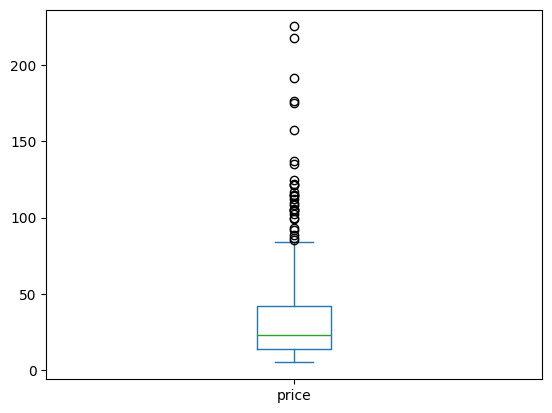

In [62]:
#Création d'une boîte à moustache de la répartition des prix grâce à Pandas
df_merge["price"].plot.box()

In [63]:
#Autre méthode avec plotly express
import plotly.express as px

# Boxplot du prix des bouteilles
fig = px.box(
    df_merge,
    y="price",
    title="Distribution des prix des bouteilles",
    points="outliers"
)

fig.write_html("Distribution des prix des bouteilles.html")

fig.show()

Une analyse univariée consiste à étudier une seule variable.
La boîte à moustaches met en évidence la médiane, l'étendue des prix et d'éventuelles valeurs atypiques (outliers), qui pourront être analysées plus en détail dans la suite de l'étude.

La visualisation de la distribution des prix permet d'observer la dispersion des prix des bouteilles:
- la majorité des bouteilles se situe entre environ 10 € et 40 €
- la médiane est autour de 20-25 €
- plusieurs bouteilles ont des prix nettement plus élevés (au-delà de 80 € et jusqu'à 220 €)

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2 - Exploration par l'utilisation de méthodes statistiques</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.1 - Identification par le Z-index</h3>
</div>

Le Z-score mesure à combien d’écarts-types une valeur se situe de la moyenne. 

Formule : Z = (x-μ)/σ

x = le prix     μ= la moyenne      σ = l'écart type

Si 7 est supérieur à 3, la valeur est considérée comme atypique (outlyer).

EN BREF  : 

Le Z-score permet d’identifier les valeurs atypiques en mesurant la distance entre une valeur et la moyenne en nombre d’écarts-types.

Un Z-score supérieur à 3 signifie que le prix est situé à plus de trois écarts-types au-dessus de la moyenne et peut donc être considéré comme une valeur atypique.

In [64]:
# Calculer la moyenne du prix
mean_price = df_merge["price"].mean()

# Calculer l'écart-type du prix
std_price = df_merge["price"].std()

# Calculer le Z-score
df_merge["z_score"] = (df_merge["price"] - mean_price) / std_price

# Afficher les premières lignes
df_merge[["price","z_score"]].head()


,price,z_score
0,24.2,-0.294738
1,34.3,0.071253
2,20.8,-0.417943
3,14.1,-0.660729
4,46.0,0.495222


les valeurs pour lesquelles Z > 3 :

In [65]:
outliers_z = df_merge[df_merge["z_score"] > 3]

outliers_z[["price","z_score"]].sort_values(by="price", ascending=False)

,price,z_score
199,225.0,6.981591
426,217.5,6.709816
587,191.3,5.760415
218,176.0,5.205993
553,175.0,5.169756
221,157.0,4.517496
381,137.0,3.792762
642,135.0,3.720288
511,124.8,3.350674
603,122.0,3.249211


In [66]:
#Quel est le seuil prix dont le z-score est supérieur à 3?
seuil_z3 = mean_price + 3 * std_price
print("Seuil de prix pour un Z-score supérieur à 3 :", seuil_z3)

Seuil de prix pour un Z-score supérieur à 3 : 115.12268073098096


Le seuil correspondant à un Z-score supérieur à 3 est d’environ 115 €.

Les bouteilles dont le prix est supérieur à ce seuil peuvent être considérées comme des valeurs atypiques car elles se situent à plus de trois écarts-types au-dessus de la moyenne.

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.2 - Identification par l'intervalle interquartile</h3>
</div>

In [67]:
#Utilisation de la fonction "describe" de Pandas pour l'étude des mesures de dispersion
df_merge["price"].describe()

count    714.000000
mean      32.333683
std       27.596332
min        5.200000
25%       14.062500
50%       23.450000
75%       42.075000
max      225.000000
Name: price, dtype: float64

In [68]:
#Définir un seuil pour les articles "outliers" en prix
# Calcul des quartiles
Q1 = df_merge["price"].quantile(0.25)
Q3 = df_merge["price"].quantile(0.75)

# Calcul de l'IQR
IQR = Q3 - Q1

# Définition des seuils
seuil_bas = Q1 - 1.5 * IQR
seuil_haut = Q3 + 1.5 * IQR

print("Seuil bas :", seuil_bas)
print("Seuil haut :", seuil_haut)

Seuil bas : -27.956250000000004
Seuil haut : 84.09375


(Le seuil bas est négatif car il provient d’un calcul statistique et ne correspond pas à un prix réel ; cela signifie simplement qu’aucun prix bas n’est considéré comme atypique dans les données)

In [69]:
#Définir le nombre d'articles et la proportion de l'ensemble du catalogue "outliers"
outliers = df_merge[(df_merge["price"] < seuil_bas) | (df_merge["price"] > seuil_haut)]

nb_outliers = outliers.shape[0]

print("Nombre d'articles outliers :", nb_outliers)

Nombre d'articles outliers : 31


In [70]:
#Selon vous, ces outliers sont-ils justifiés ? Comment le démontrer si cela est possible ?
proportion = nb_outliers / df_merge.shape[0]

print("Proportion d'outliers :", proportion)
print("Proportion d'outliers :", proportion * 100, "%")

Proportion d'outliers : 0.04341736694677871
Proportion d'outliers : 4.341736694677871 %


Les outliers correspondent aux bouteilles dont le prix dépasse le seuil défini par la méthode de l’intervalle interquartile.

Ces bouteilles représentent une faible proportion du catalogue. Il est possible qu’il s’agisse de vins haut de gamme, mais il est également nécessaire de vérifier qu’il ne s’agit pas d’erreurs de saisie.

autrement dit : Les outliers sont des bouteilles dont le prix est beaucoup plus élevé que la majorité des vins. Cela peut être normal si ce sont des vins de prestige, mais il faut vérifier qu’il ne s’agit pas d’une erreur de saisie.

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Analyse univariée du CA, des quantités vendues, des stocks et de la marge ainsi qu'une analyse multivariée  </h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.1 - Analyse des ventes en CA</h3>
</div>

CA = prix × quantité vendue

In [71]:
##############################
# Calculer le CA du site web #
##############################

#Créer une colonne calculant le CA par article
df_merge["ca_par_article"] = df_merge["price"] * df_merge["total_sales"]

#Calculer la somme de la colonne "ca_par_article"
ca_total = df_merge["ca_par_article"].sum()

#Ce résultat correspond au chiffre d'affaire du site web
print(f"Chiffre d'affaires total du site web : {ca_total:.2f} €")

Chiffre d'affaires total du site web : 153748.10 €


In [72]:
###############################
# Palmarès des articles en CA #
###############################

#Effectuer le tri dans l'ordre décroissant du CA du dataset df_merge
df_ca = df_merge.sort_values(by="ca_par_article", ascending=False)

#Réinitialiser l'index du dataset par un reset_index
df_ca = df_ca.reset_index(drop=True)

#Afficher les 20 premiers articles en CA
top20_ca = df_ca.head(20)
top20_ca[["product_id", "post_title", "price", "total_sales", "ca_par_article"]]

#Graphique en barre des 20 premiers articles avec plotly express
fig = px.bar(
    top20_ca.sort_values("ca_par_article"),
    x="ca_par_article",
    y="post_title",
    orientation="h",
    title="Top 20 des vins générant le plus de chiffre d'affaires pour le mois d'octobre",
    custom_data=["post_title", "ca_par_article", "total_sales"]
)

fig.update_layout(
    xaxis_title="Chiffre d'affaires généré (€)",
    yaxis_title="Nom produit"
)

fig.update_traces(
    hovertemplate="<b>%{customdata[0]}</b><br>%{customdata[1]:.0f} € de chiffre d'affaires généré<br>pour %{customdata[2]} bouteilles vendues<extra></extra>"
)
fig.write_html("top20_ca_octobre.html")
fig.show()

In [73]:
fig.write_html("graphique_ca.html")

In [74]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part du CA de la ligne dans le dataset
df_ca["part_ca"] = df_ca["ca_par_article"] / ca_total

#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_ca["ca_cumule"] = df_ca["part_ca"].cumsum()

#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% du CA
nb_articles_80 = df_ca[df_ca["ca_cumule"] <= 0.80].shape[0]

#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
proportion_80 = nb_articles_80 / df_merge.shape[0]

print(f"Nombre d'articles représentant 80 % du CA d'octobre : {nb_articles_80}")
print(f"Proportion du catalogue concernée : {proportion_80*100:.2f} %")

Nombre d'articles représentant 80 % du CA d'octobre : 420
Proportion du catalogue concernée : 58.82 %


Sur le CA web d’octobre, 420 vins, soit 58,82 % du catalogue, génèrent 80 % du chiffre d’affaires. Les ventes sont donc réparties sur un grand nombre de références.

REMARQUE :

Normalement, avec la règle Pareto 20/80, on s’attendrait plutôt à :

20 % des produits → 80 % du CA

Mais ici on observe :

58,82 % des produits → 80 % du CA

Donc :

➡️ les ventes sont moins concentrées que prévu
➡️ le chiffre d’affaires est réparti sur beaucoup de références

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.2 - Analyse des ventes en quantité</h3>
</div>

In [75]:
#####################################
# Palmarès des articles en quantité #
#####################################

#Effectuer le tri dans l'ordre décroissant de quantités vendues du dataset df_merge
df_quantite = df_merge.sort_values(by="total_sales", ascending=False)

#Réinitialiser l'index du dataset par un reset_index
df_quantite = df_quantite.reset_index(drop=True)

#Afficher les 20 premiers articles en quantité
top20_quantite = df_quantite.head(20)
display(top20_quantite)

#Graphique en barre des 20 premiers articles avec plotly express
import plotly.express as px

# Inverser l'ordre pour avoir le plus vendu en haut
top20_quantite = top20_quantite.sort_values("total_sales", ascending=True)

fig = px.bar(
    top20_quantite,
    x="total_sales",
    y="post_title",
    orientation="h",
    title="Top 20 des articles les plus vendus en quantité du 1er au 31 octobre",
    labels={
        "total_sales": "Nombre de produits vendus",
        "post_title": "Nom produit"
    }
)
fig.write_html("top20_quantite_octobre.html")
fig.show()

,product_id,onsale_web,price,stock_quantity,purchase_price,stock_status,price_for_analysis,id_web,sku,total_sales,...,comment_status,ping_status,post_name,post_modified,post_modified_gmt,guid,post_type,post_mime_type,z_score,ca_par_article
0,4726,1,12.7,0,6.82,outofstock,12.7,14950,14950,122.0,...,closed,closed,francois-baur-pinot-noir-schlittweg-2017,2020-05-06 11:35:01,2020-05-06 09:35:01,https://www.bottle-neck.fr/wp-content/uploads/...,attachment,image/jpeg,-0.711460,1549.4
1,4150,1,59.0,123,35.45,instock,59.0,1366,1366,116.0,...,closed,closed,champagne-mailly-grand-cru-intemporelle-2010,2020-08-26 18:05:02,2020-08-26 16:05:02,https://www.bottle-neck.fr/wp-content/uploads/...,attachment,image/jpeg,0.966299,6844.0
2,5379,1,11.1,33,5.68,instock,11.1,14561,14561,111.0,...,closed,closed,argentine-mendoza-alamos-torrontes-2017,2020-07-11 14:00:03,2020-07-11 12:00:03,https://www.bottle-neck.fr/wp-content/uploads/...,attachment,image/jpeg,-0.769439,1232.1
3,4867,1,9.9,121,4.86,instock,9.9,16148,16148,36.0,...,closed,closed,chateau-de-la-selve-igp-coteaux-de-lardeche-ma...,2020-08-27 09:30:15,2020-08-27 07:30:15,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,-0.812923,356.4
4,4203,1,9.9,74,5.01,instock,9.9,15415,15415,27.0,...,closed,closed,mas-laval-igp-pays-herault-pampres-blanc-2018,2020-07-11 16:45:03,2020-07-11 14:45:03,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,-0.812923,267.3
5,4275,1,14.9,62,7.78,instock,14.9,14864,14864,24.0,...,closed,closed,i-fabbri-chianti-classico-lamole-2017,2020-08-22 14:35:02,2020-08-22 12:35:02,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,-0.631739,357.6
6,5067,1,59.9,3,30.95,instock,59.9,15346,15346,22.0,...,closed,closed,albert-mann-pinot-noir-grand-h-2017,2020-02-13 17:00:01,2020-02-13 16:00:01,https://www.bottle-neck.fr/wp-content/uploads/...,attachment,image/jpeg,0.998912,1317.8
7,4647,1,28.5,45,14.14,instock,28.5,16525,16525,22.0,...,closed,closed,bernard-baudry-chinon-rouge-croix-boissee-2017,2020-07-31 09:31:39,2020-07-31 07:31:39,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,-0.138920,627.0
8,5826,1,41.2,34,21.71,instock,41.2,15325,15325,20.0,...,closed,closed,agnes-levet-amethyste-2017,2020-05-21 14:00:02,2020-05-21 12:00:02,https://www.bottle-neck.fr/wp-content/uploads/...,attachment,image/jpeg,0.321286,824.0
9,6129,1,5.2,68,2.74,instock,5.2,14570,14570,20.0,...,closed,closed,moulin-de-gassac-igp-pays-dherault-guilhem-bla...,2020-08-26 15:55:02,2020-08-26 13:55:02,https://www.bottle-neck.fr/?post_type=product&...,product,NaN,-0.983235,104.0


In [76]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part en quantité de la ligne dans le dataset
df_20_80_quantite = df_merge.sort_values(by="total_sales", ascending=False).reset_index(drop=True)

#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_20_80_quantite["part_quantite"] = df_20_80_quantite["total_sales"] / df_20_80_quantite["total_sales"].sum()

#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% des ventes en quantité
df_20_80_quantite["part_quantite_cumulee"] = df_20_80_quantite["part_quantite"].cumsum()
nb_articles_80_quantite = (df_20_80_quantite["part_quantite_cumulee"] <= 0.80).sum() + 1

#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
proportion_catalogue_quantite = (nb_articles_80_quantite / df_20_80_quantite.shape[0]) * 100

print("Nombre d'articles représentant 80% des ventes du catalogue en quantité :", nb_articles_80_quantite)
print("Proportion du catalogue concernée : {:.2f}%".format(proportion_catalogue_quantite))

Nombre d'articles représentant 80% des ventes du catalogue en quantité : 425
Proportion du catalogue concernée : 59.52%


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.3 - Analyse des stocks</h3>
</div>

In [77]:
######################################
# Calculer le nombre de mois de stock #
######################################

#Import de numpy 
import numpy as np

#Création de la colonne Rotation de stock
df_merge["rotation_stock"] = df_merge["stock_quantity"] / df_merge["total_sales"]

#Remplacement des "inf" par 0
df_merge["rotation_stock"] = df_merge["rotation_stock"].replace([np.inf, -np.inf], 0)

#Effectuer le tri dans l'ordre décroissant du nombre de mois de stock dans le dataset df_merge
df_stock = df_merge.sort_values(by="rotation_stock", ascending=False).reset_index(drop=True)

#Graphique en barre du flop 20 des produits qui ont le plus de mois de stock
flop20_stock = df_stock.head(20)

import plotly.express as px

fig = px.bar(
    flop20_stock.sort_values("rotation_stock", ascending=True),
    x="rotation_stock",
    y="post_title",
    orientation="h",
    title="Top 20 des produits les plus longtemps stockés",
    labels={
        "rotation_stock": "Stockage en nombre de mois",
        "post_title": "Nom produit"
    }
)
fig.write_html("top20_stock_octobre.html")
fig.show()

In [78]:
####################################
# Valorisation des stocks en euros #
####################################

# Création de la colonne Valorisation des stocks en euros
df_merge["Valorisation_stock_euros"] = df_merge["stock_quantity"] * df_merge["purchase_price"]

# Calculer la somme de la colonne "Valorisation_stock_euros"
valorisation_totale_stock = df_merge["Valorisation_stock_euros"].sum()

print("Valorisation totale du stock : {:.2f} €".format(valorisation_totale_stock))

Valorisation totale du stock : 277305.77 €


In [79]:
##############################################
# Valorisation du nombre de produits en stock #
##############################################

#Calculer la somme de la colonne stock quantity
nb_total_produits_stock = df_merge["stock_quantity"].sum()


print("Nombre total de produits en stock :", nb_total_produits_stock)

Nombre total de produits en stock : 16739


16739 bouteilles sont en stock pour une valeur totale estimée à 277 305,77 €.
La valorisation correspond au montant d’argent immobilisé dans les produits encore présents en stock, calculé à partir du prix d’achat des bouteilles multiplié par la quantité restante.

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.4 - Analyse du taux de marge</h3>
</div>

taux_marge = purchase_price - price−purchase_price / purchase_price
	​


cad : le taux de marge est égal à la différence entre le prix de vente et le prix d'achat divisé ensuite par le prix d'achat

In [80]:
############################
# Analyse du taux de marge #
############################

#Création de la colonne Prix HT
df_merge["prix_ht"] = df_merge["price"]

#Création de la colonne Taux de marge
df_merge["taux_marge"] = ((df_merge["prix_ht"] - df_merge["purchase_price"]) / df_merge["purchase_price"]) * 100

#Afficher le prix minimum de la colonne "taux_marge"
print("Taux de marge minimum :", df_merge["taux_marge"].min())

#Afficher le prix maximum de la colonne "taux_marge"
print("Taux de marge maximum :", df_merge["taux_marge"].max())

Taux de marge minimum : -83.67320598864222
Taux de marge maximum : 129.6949650863653


Le taux de marge minimum est en négatif, celà veut dire qu'au moins un produit est vendu à perte. Je calcule combien de produits dans ce cas :

In [81]:
produits_perte = df_merge[df_merge["price"] < df_merge["purchase_price"]]
print("Nombre de produits vendus à perte :", produits_perte.shape[0])

Nombre de produits vendus à perte : 1


1 seul produit est vendu à perte, je l'identifie et je le signale dans le journal d'erreur pour l'exercice. dans la réalité, j'avertirai immédiatement Bottleneck.

In [82]:
#Affichage de la ligne avec un taux de marge inférieur à 0
produits_perte = df_merge[df_merge["taux_marge"] < 0]

display(produits_perte[[
    "post_title",
    "price",
    "purchase_price",
    "taux_marge"
]])

,post_title,price,purchase_price,taux_marge
201,Champagne Egly-Ouriet Grand Cru Blanc de Noirs,12.65,77.48,-83.673206


In [83]:
# Création d'un dataframe avec les taux positifs
df_marge_positive = df_merge[df_merge["taux_marge"] >= 0]

# Afficher le prix minimum de la colonne "taux_marge"
print("Taux de marge minimum :", df_marge_positive["taux_marge"].min())

# Afficher le prix maximum de la colonne "taux_marge"
print("Taux de marge maximum :", df_marge_positive["taux_marge"].max())

Taux de marge minimum : 55.39739027283511
Taux de marge maximum : 129.6949650863653


Après exclusion des produits présentant une marge négative, l’analyse montre que le taux de marge varie entre 0.55... et 1,29... pour les produits rentables.

In [84]:
# Création du dataframe avec la marge moyenne par type
df_marge_type = df_marge_positive.groupby("product_type")["taux_marge"].mean().reset_index()

# Tri du plus élevé au plus faible
df_marge_type = df_marge_type.sort_values("taux_marge", ascending=False)

fig = px.bar(
    df_marge_type,
    x="taux_marge",
    y="product_type",
    orientation="h",
    text="taux_marge",
    title="Taux de marge moyen par type de produit",
    labels={
        "product_type": "Type de produit",
        "taux_marge": "Taux de marge moyen (%)"
    }
)

fig.update_yaxes(autorange="reversed")

fig.update_traces(
    texttemplate='%{text:.1f} %',
    textposition='outside',
    hovertemplate="Taux de marge moyen : %{x:.1f}%<br>Type de produit : %{y}<extra></extra>"
)

fig.write_html("taux_marge_moyen_par_type_produit_octobre.html")
fig.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.5 - Analyse des corrélations entre les variables stock, sales et price</h3>
</div>

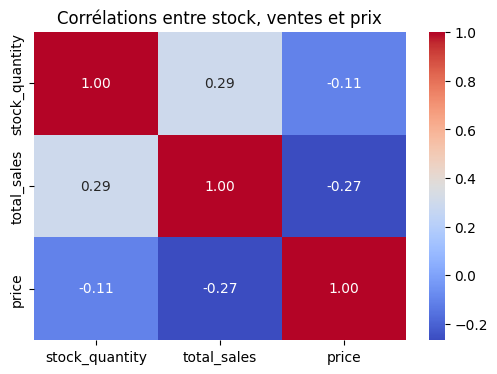

In [85]:
############################
# Analyse des corrélations #
############################

# Importation de Seaborn
import seaborn as sns
import matplotlib.pyplot as plt

# Sélection des variables à analyser
corr_variables = df_merge[["stock_quantity", "total_sales", "price"]]

# Calcul de la matrice de corrélation
corr_matrix = corr_variables.corr()

# Création de la heatmap
plt.figure(figsize=(6,4))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Corrélations entre stock, ventes et prix")
plt.show()

La corrélation varie entre :

1 → corrélation positive forte

0 → aucune relation

-1 → corrélation négative forte

In [86]:
#Que peut-on conclure des corrélations ?

Les corrélations observées sont globalement faibles. On remarque une légère corrélation positive entre le stock et les ventes (0,29), ce qui suggère que les produits les plus vendus sont généralement davantage stockés. En revanche, le prix présente une corrélation légèrement négative avec les ventes (-0,27), indiquant que les produits plus chers ont tendance à se vendre un peu moins.

Les relations observées sont cohérentes avec le fonctionnement habituel du marché du vin : les produits plus accessibles se vendent davantage, tandis que les produits plus chers ont une rotation plus faible. Les niveaux de stock semblent globalement alignés avec la demande.

In [87]:
# Segmentation Pareto à partir du CA
df_ca_pareto = df_merge.sort_values(by="ca_par_article", ascending=False).reset_index(drop=True)
df_ca_pareto["part_ca"] = df_ca_pareto["ca_par_article"] / df_ca_pareto["ca_par_article"].sum()
df_ca_pareto["ca_cumule"] = df_ca_pareto["part_ca"].cumsum()

# Groupes
df_top20 = df_ca_pareto[df_ca_pareto["ca_cumule"] <= 0.20]
df_bottom20 = df_ca_pareto[df_ca_pareto["ca_cumule"] >= 0.80]

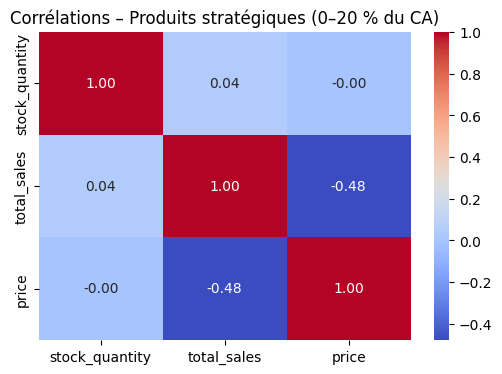

In [88]:
# Corrélations 0-20 % du CA
corr_top20 = df_top20[["stock_quantity", "total_sales", "price"]].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr_top20, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Corrélations – Produits stratégiques (0–20 % du CA)")
plt.show()

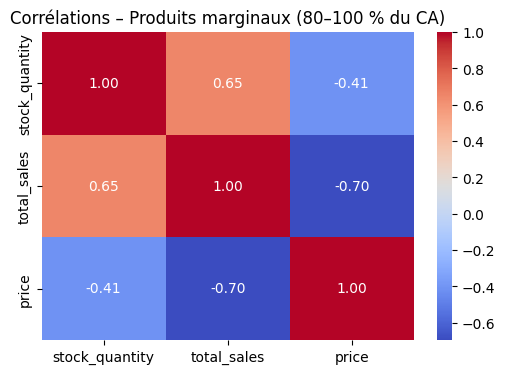

In [89]:
# Corrélations 80-100 % du CA
corr_bottom20 = df_bottom20[["stock_quantity", "total_sales", "price"]].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr_bottom20, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Corrélations – Produits marginaux (80–100 % du CA)")
plt.show()

In [90]:
print("Nombre de références dans le groupe 0-20% :", df_top20.shape[0])
print("Nombre de références dans le groupe 80-100% :", df_bottom20.shape[0])

Nombre de références dans le groupe 0-20% : 32
Nombre de références dans le groupe 80-100% : 294


In [91]:
ca_total = df_merge["ca_par_article"].sum()

In [92]:
ca_top20 = df_top20["ca_par_article"].sum()

print("Part du CA des références 0-20% :", round(ca_top20 / ca_total * 100,2), "%")

Part du CA des références 0-20% : 19.94 %


In [93]:
ca_bottom20 = df_bottom20["ca_par_article"].sum()

print("Part du CA des références 80-100% :", round(ca_bottom20 / ca_total * 100,2), "%")

Part du CA des références 80-100% : 20.09 %


In [94]:
df_pareto = df_merge.sort_values(by="ca_par_article", ascending=False).reset_index(drop=True)

df_pareto["part_ca"] = df_pareto["ca_par_article"] / df_pareto["ca_par_article"].sum()
df_pareto["ca_cumule"] = df_pareto["part_ca"].cumsum()

df_0_20 = df_pareto[df_pareto["ca_cumule"] <= 0.20]
df_20_80 = df_pareto[(df_pareto["ca_cumule"] > 0.20) & (df_pareto["ca_cumule"] <= 0.80)]
df_80_100 = df_pareto[df_pareto["ca_cumule"] > 0.80]

In [95]:
nb_0_20 = df_0_20.shape[0]
nb_20_80 = df_20_80.shape[0]
nb_80_100 = df_80_100.shape[0]

print("Nombre de produits 0–20% :", nb_0_20)
print("Nombre de produits 20–80% :", nb_20_80)
print("Nombre de produits 80–100% :", nb_80_100)

Nombre de produits 0–20% : 32
Nombre de produits 20–80% : 388
Nombre de produits 80–100% : 294


In [96]:
import pandas as pd

# CA total
ca_total = df_pareto["ca_par_article"].sum()

# Fonction pour résumer chaque groupe
def resume_groupe(df_groupe, nom):
    return {
        "Tranche Pareto": nom,
        "Nb produits": df_groupe.shape[0],
        "CA total (€)": df_groupe["ca_par_article"].sum(),
        "% du CA": round(df_groupe["ca_par_article"].sum() / ca_total * 100, 1),
        "Prix moyen (€)": round(df_groupe["price"].mean(),2),
        "Prix min (€)": round(df_groupe["price"].min(),2),
        "Prix max (€)": round(df_groupe["price"].max(),2),
        "Rotation stock moyenne": round(df_groupe["rotation_stock"].mean(),2)
    }

table_pareto = pd.DataFrame([
    resume_groupe(df_0_20, "0–20%"),
    resume_groupe(df_20_80, "20–80%"),
    resume_groupe(df_80_100, "80–100%")
])

table_pareto

,Tranche Pareto,Nb produits,CA total (€),% du CA,Prix moyen (€),Prix min (€),Prix max (€),Rotation stock moyenne
0,0–20%,32,30662.6,19.9,91.53,11.1,225.0,5.56
1,20–80%,388,92192.0,60.0,35.11,9.5,217.5,2.90
2,80–100%,294,30893.5,20.1,22.22,5.2,124.8,2.67


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.6 - Mise à disposition de la nouvelle table sur un fichier Excel</h3>
</div>

In [97]:
#Mettre le dataset df_merge sur un fichier Excel
df_merge.to_excel("bottleneck_dataset_final.xlsx", index=False)

#Cette étape peut être utile pour partager le résultat du dataset obtenu avec les équipes.  


Le dataset final consolidé a été exporté au format Excel afin de faciliter son partage et son utilisation par les équipes métier.